## Wimbledon

We have 127 Wimbledon matches to test our model.

### input

model takes in these features in order:


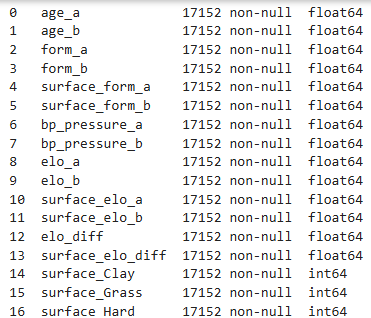


and will output a probability.

In [25]:
# data analytics + math
import pandas as pd 
import numpy as np 

# data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# other stuff used for later (need sci-kit learn too)
import xgboost # just installed it using !pip install

# set some parameters for pandas to view the data a bit better
pd.set_option('display.max_columns', 50) # see ALL columns
pd.set_option('display.width', 150)

# NOTE: this data is missing Sinner - Djokovic SF, and Sinner - Zverev F
df = pd.read_csv("data/wimbledon.csv")

print(df.info())

# print(df.tail())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125 entries, 0 to 124
Data columns (total 50 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   tourney_id          125 non-null    object 
 1   tourney_name        125 non-null    object 
 2   surface             125 non-null    object 
 3   draw_size           125 non-null    int64  
 4   tourney_level       125 non-null    object 
 5   indoor              125 non-null    object 
 6   tourney_date        125 non-null    int64  
 7   match_num           125 non-null    int64  
 8   winner_id           125 non-null    object 
 9   winner_seed         59 non-null     float64
 10  winner_entry        22 non-null     object 
 11  winner_name         125 non-null    object 
 12  winner_hand         125 non-null    object 
 13  winner_ht           125 non-null    int64  
 14  winner_ioc          125 non-null    object 
 15  winner_age          124 non-null    float64
 16  winner_r

### player stats

we have a trusty file called ```player_stats.csv``` that has all players and their most recent stats.

In [15]:
players = pd.read_csv("data/player_stats.csv")

players.set_index('player', inplace=True)
players.loc['Arthur Fery'] # this guy is gonna cause a problem...

rank            140.000000
age              23.937000
elo            1571.870955
recent_form       0.500000
bp_pressure       8.800000
grass_elo      1510.185698
grass_form        0.500000
clay_elo       1500.000000
clay_form         0.500000
hard_elo       1527.820455
hard_form         0.500000
Name: Arthur Fery, dtype: float64

### restructuring into model inputs

Basically, we want to use the Wimbledon data along with our ```player_stats.csv``` to have inputs for our model.

In [23]:
def restructure_wimbledon(df):
    df_a = pd.DataFrame({
        'player_a': df['winner_name'],
        'player_b': df['loser_name'],
        'label':    1
    })
    df_b = pd.DataFrame({
        'player_a': df['loser_name'],
        'player_b': df['winner_name'],
        'label':    0
    })
    return pd.concat([df_a, df_b], ignore_index=True)

wim = restructure_wimbledon(df)


wim

,player_a,player_b,label
0,Marton Fucsovics,Luca Van Assche,1
1,Rafael Jodar,Felix Gill,1
2,Jenson Brooksby,Aleksandar Vukic,1
3,Pablo Carreno Busta,Denis Shapovalov,1
4,Shintaro Mochizuki,Max Basing,1
...,...,...,...
245,Jiri Lehecka,Alexander Zverev,0
246,Felix Auger-Aliassime,Novak Djokovic,0
247,Taylor Fritz,Alexander Zverev,0
248,Flavio Cobolli,Arthur Fery,0


In [54]:
### iterating over the players + filling in the data
rows = []
for _, row in wim.iterrows():
    try:
        stats_a = players.loc[row['player_a']]
        stats_b = players.loc[row['player_b']]

        
        
        rows.append({
            'player_a':         row['player_a'],
            'player_b':         row['player_b'],
            'label':            row['label'],
            'age_a':            stats_a['age'],
            'age_b':            stats_b['age'],
            'form_a':           stats_a['recent_form'],
            'form_b':           stats_b['recent_form'],
            'surface_form_a':   stats_a['grass_form'],
            'surface_form_b':   stats_b['grass_form'],
            'bp_pressure_a':    stats_a['bp_pressure'],
            'bp_pressure_b':    stats_b['bp_pressure'],
            'elo_a':            stats_a['elo'],
            'elo_b':            stats_b['elo'],
            'surface_elo_a':    stats_a['grass_elo'],
            'surface_elo_b':    stats_b['grass_elo'],
            'elo_diff':         stats_a['elo'] - stats_b['elo'],
            'surface_elo_diff': stats_a['grass_elo'] - stats_b['grass_elo'],
            'surface_Clay':     0,
            'surface_Grass':    1, # because Wimbledon!
            'surface_Hard':     0,
        })
    except KeyError as e:
        print(e)
data = pd.DataFrame(rows)

data

# note: there are 123 * 2 rows in total
# 125 originally but we skipped Max Basing and Felix Gill (both lost 1st round) so 123

'Felix Gill'
'Max Basing'
'Felix Gill'
'Max Basing'


,player_a,player_b,label,age_a,age_b,form_a,form_b,surface_form_a,surface_form_b,bp_pressure_a,bp_pressure_b,elo_a,elo_b,surface_elo_a,surface_elo_b,elo_diff,surface_elo_diff,surface_Clay,surface_Grass,surface_Hard
0,Marton Fucsovics,Luca Van Assche,1,34.352,22.048,0.3,0.6,0.500,0.333333,5.8,8.4,1596.362887,1613.754578,1642.324003,1451.221409,-17.391691,191.102594,0,1,0
1,Jenson Brooksby,Aleksandar Vukic,1,25.640,30.133,0.2,0.4,0.600,0.400000,7.3,6.3,1553.692582,1526.482512,1604.445790,1490.442291,27.210069,114.003499,0,1,0
2,Pablo Carreno Busta,Denis Shapovalov,1,34.886,27.173,0.5,0.3,0.400,0.500000,5.8,7.3,1714.520409,1585.497330,1488.350785,1509.862917,129.023079,-21.512132,0,1,0
3,Learner Tien,Dalibor Svrcina,1,20.539,23.595,0.8,0.6,0.625,0.500000,8.1,6.9,1884.832283,1615.089395,1560.090320,1500.000000,269.742888,60.090320,0,1,0
4,Tommy Paul,Alexandre Muller,1,29.095,29.311,0.8,0.3,0.800,0.333333,5.8,7.9,1919.627079,1509.908214,1743.860709,1491.179436,409.718866,252.681273,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
241,Jiri Lehecka,Alexander Zverev,0,24.608,29.166,0.6,1.0,0.800,0.700000,3.9,3.1,1835.617383,2146.503810,1693.302080,1758.056562,-310.886427,-64.754482,0,1,0
242,Felix Auger-Aliassime,Novak Djokovic,0,25.862,39.020,0.7,0.7,0.700,0.800000,5.5,8.6,1876.398354,2055.203766,1641.050583,2006.370483,-178.805412,-365.319900,0,1,0
243,Taylor Fritz,Alexander Zverev,0,28.646,29.166,0.7,1.0,0.800,0.700000,4.2,3.1,1896.856222,2146.503810,1910.009123,1758.056562,-249.647588,151.952561,0,1,0
244,Flavio Cobolli,Arthur Fery,0,24.110,23.937,0.6,0.5,0.700,0.500000,7.6,8.8,1908.415855,1571.870955,1637.872797,1510.185698,336.544899,127.687099,0,1,0


### testing model

now we test our model saved as ```tennis_model_xgb.pkl```

In [73]:
import pickle
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score


model = pickle.load(open('tennis_model_xgb.pkl', 'rb'))

# our features in this order
FEATURES = [
    'age_a', 'age_b',
    'form_a', 'form_b',
    'surface_form_a', 'surface_form_b',
    'bp_pressure_a', 'bp_pressure_b',
    'elo_a', 'elo_b',
    'surface_elo_a', 'surface_elo_b',
    'elo_diff', 'surface_elo_diff',
    'surface_Clay', 'surface_Grass', 'surface_Hard',
]



X = data[FEATURES] 
y = data['label']

y_pred = model.predict(X)
y_pred_proba = model.predict_proba(X)[:, 1]

accuracy = accuracy_score(y, y_pred)

# naive
naive = (data['elo_a'] > data['elo_b']).astype(int)
naive_accuracy = accuracy_score(y, naive)

print(f"Accuracy: {accuracy*100}")
print(f"Naive Accuracy: {naive_accuracy*100}")

Accuracy: 62.601626016260155
Naive Accuracy: 60.16260162601627


In [87]:
wim_features = data
    
wim_features['predicted_proba'] = y_pred_proba
wim_features['predicted_label'] = y_pred
wim_features['correct'] = (y_pred == y).astype(int)


# Matches the model got wrong
wrong = wim_features[wim_features['correct'] != 1][
    ['player_a', 'player_b', 'predicted_proba', 'label']
].sort_values('predicted_proba', ascending=False)

print(data[data['player_a'] == "Luciano Darderi"])

            player_a     player_b  label   age_a   age_b  form_a  form_b  surface_form_a  surface_form_b  bp_pressure_a  bp_pressure_b        elo_a  \
138  Luciano Darderi  Ethan Quinn      0  24.285  22.267     0.7     0.3            0.25        0.555556            6.0            5.6  1828.323646   

           elo_b  surface_elo_a  surface_elo_b    elo_diff  surface_elo_diff  surface_Clay  surface_Grass  surface_Hard  predicted_proba  \
138  1562.991542    1427.158274    1557.726989  265.332104       -130.568715             0              1             0         0.474757   

     predicted_label  correct  
138                0        1  


### other stuff

Sinner - Djokovic's SF match isn't recorded here. As is the same with Sinner - Zverev F match. It'll be much easier in the future, or if I am just curious about something, to make a function that simply takes in two names and outputs a probability prediction on who's going to win.

In [101]:
def versus(player_a, player_b):
    try:
        stats_a = players.loc[player_a]
        stats_b = players.loc[player_b]
        
        info = pd.DataFrame([{
            'player_a':         row['player_a'],
            'player_b':         row['player_b'],
            'label':            row['label'],
            'age_a':            stats_a['age'],
            'age_b':            stats_b['age'],
            'form_a':           stats_a['recent_form'],
            'form_b':           stats_b['recent_form'],
            'surface_form_a':   stats_a['grass_form'],
            'surface_form_b':   stats_b['grass_form'],
            'bp_pressure_a':    stats_a['bp_pressure'],
            'bp_pressure_b':    stats_b['bp_pressure'],
            'elo_a':            stats_a['elo'],
            'elo_b':            stats_b['elo'],
            'surface_elo_a':    stats_a['grass_elo'],
            'surface_elo_b':    stats_b['grass_elo'],
            'elo_diff':         stats_a['elo'] - stats_b['elo'],
            'surface_elo_diff': stats_a['grass_elo'] - stats_b['grass_elo'],
            'surface_Clay':     0,
            'surface_Grass':    1, # because Wimbledon!
            'surface_Hard':     0,
        }])
    except KeyError as e:
        print(f"An error occured: {e}")

    X = info[FEATURES]
    
    y_pred_proba = model.predict_proba(X)[:, 1][0]
    
    print(f"{player_a} wins over {player_b}: {y_pred_proba*100}%" if y_pred_proba > 0.5 else f"{player_b} wins over {player_a}: {100-y_pred_proba*100}%")

versus("Novak Djokovic", "Carlos Alcaraz")


Carlos Alcaraz wins over Novak Djokovic: 79.79769897460938%
